This notebook is meant to be run on the HPC via Europa. Instructions are here:
* https://github.com/NREL/HPC/tree/master/general/Jupyterhub/jupyter

In [50]:
import numpy as np
# import gdxpds
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import os, sys, math, site, shutil, importlib
from tqdm import tqdm, trange
from glob import glob

import geopandas as gpd
import h5py

# ### ReEDS: SA_NTPS branch
# reedspath = os.path.expanduser('~/github/ReEDS-2.0/')
# reedspath2 = os.path.expanduser('~/github2/ReEDS-2.0/')
# remotepath = '/Volumes/ReEDS/'
# projpath = os.path.expanduser('~/Projects/SpatialTemporal/')


# reedspath = reedspath2


# site.addsitedir(os.path.join(reedspath,'postprocessing'))
# import plots
# import reedsplots as rplots
# importlib.reload(rplots)

pd.options.display.max_columns = 200

# CSP profile files

In [51]:
inpath = '/shared-projects/rev/projects/csp_conus/csp/'
year = 2012
infile = os.path.join(inpath,f'csp_gen_{year}.h5')

with h5py.File(infile, 'r') as f:
    keys = list(f)
    for key in keys:
        print(key)
#         display(pd.DataFrame(f[key]))

    meta = pd.DataFrame(f['meta'][...])
    meta['cf_mean'] = pd.DataFrame(f['cf_mean'][...])
    meta['dni_mean'] = pd.DataFrame(f['dni_mean'][...])
    meta['lcoe_real'] = pd.DataFrame(f['lcoe_real'][...])
    time_index = pd.DataFrame(f['time_index'][...])

for c in ['country','state','county','urban','reV_tech']:
    meta[c] = meta[c].str.decode('UTF-8')

time_index = time_index[0].str.decode('UTF-8')[::2]

cf_mean
cf_profile
dni_mean
lcoe_real
meta
time_index


In [3]:
# os.makedirs(os.path.expanduser('~/reV'), exist_ok=True)
# meta.to_hdf(
#     os.path.expanduser('~/reV/csp_meta.h5'),
#     key='data', complevel=4)

In [ ]:
# meta.to_csv(os.path.expanduser('~/reV/csp/csp_meta.csv.gz'), index=False)

In [ ]:
meta

In [ ]:
print(meta.cf_mean.describe())
dfplot = meta.loc[meta.cf_mean>=156].copy()

In [ ]:
plt.close()
f,ax = plt.subplots(figsize=(13,8))
ax.scatter(
    dfplot.longitude, dfplot.latitude, c=dfplot.dni_mean,
    s=0.6, lw=0, marker='s', cmap=plt.cm.gist_earth_r, vmin=0,
)
plt.show()

In [ ]:
with h5py.File(infile, 'r') as f:
    cf_profile = pd.DataFrame(f['cf_profile'][:,:5])

In [ ]:
cf_profile.iloc[:24*2*7].plot()

In [ ]:
plt.close()
f,ax = plt.subplots()
cf_profile[0].sort_values().reset_index(drop=True).plot(ax=ax)
ax.set_yscale('log')
plt.show()

In [ ]:
cf_profile.describe()

In [ ]:
df = cf_profile.astype(float)/1000
df[0].loc[df[0] < 0.01] = 0

In [ ]:
plt.close()
f,ax = plt.subplots()
df[0].sort_values().reset_index(drop=True).plot(ax=ax)
ax.set_yscale('log')
plt.show()

In [ ]:
df[0].replace(0,np.nan).dropna().sort_values()

In [ ]:
with h5py.File(infile, 'r') as f:
    cf_hour0 = pd.DataFrame(f['cf_profile'][0,:])

# Assemble profiles

In [52]:
inpath = '/shared-projects/rev/projects/csp_conus/csp/'
years = list(range(2007, 2014))

# cffile = 
# with h5py.File(infile, 'r') as f:
#     cf_profile = pd.DataFrame(f['cf_profile'][:,:5])

In [53]:
### Get supply curve
dfsc = gpd.read_file(
    os.path.expanduser('~/reV/csp/vision_sn2_csp_conus_2012-sc_point_gid.gpkg')
)

In [54]:
dfsc.groupby('sc_point_gid').profile_index.count()

sc_point_gid
5372     1
5373     1
5750     1
5751     2
5752     3
        ..
97459    3
97460    2
97461    3
97462    4
97463    2
Name: profile_index, Length: 24722, dtype: int64

In [55]:
dfsc.groupby('sc_point_gid').profile_index.unique().map(lambda x: len(x)).sort_values()

sc_point_gid
5372     1
64386    1
64385    1
64384    1
64383    1
        ..
42608    1
42606    1
42605    1
42367    1
97463    1
Name: profile_index, Length: 24722, dtype: int64

In [56]:
sc_point_gids = sorted(dfsc.sc_point_gid.unique())
print(len(sc_point_gids))

24722


In [57]:
timeindex = {
    y: pd.date_range(f'{y}-01-01', f'{y+1}-01-01', closed='left', freq='H', tz='EST')[:8760]
    for y in range(2007,2014)
}

fulltimeindex = pd.concat([pd.Series(index=t, dtype=float) for t in timeindex.values()]).index
fulltimeindex

DatetimeIndex(['2007-01-01 00:00:00-05:00', '2007-01-01 01:00:00-05:00',
               '2007-01-01 02:00:00-05:00', '2007-01-01 03:00:00-05:00',
               '2007-01-01 04:00:00-05:00', '2007-01-01 05:00:00-05:00',
               '2007-01-01 06:00:00-05:00', '2007-01-01 07:00:00-05:00',
               '2007-01-01 08:00:00-05:00', '2007-01-01 09:00:00-05:00',
               ...
               '2013-12-31 14:00:00-05:00', '2013-12-31 15:00:00-05:00',
               '2013-12-31 16:00:00-05:00', '2013-12-31 17:00:00-05:00',
               '2013-12-31 18:00:00-05:00', '2013-12-31 19:00:00-05:00',
               '2013-12-31 20:00:00-05:00', '2013-12-31 21:00:00-05:00',
               '2013-12-31 22:00:00-05:00', '2013-12-31 23:00:00-05:00'],
              dtype='datetime64[ns, EST]', length=61320, freq=None)

In [58]:
timeindex[2012]

DatetimeIndex(['2012-01-01 00:00:00-05:00', '2012-01-01 01:00:00-05:00',
               '2012-01-01 02:00:00-05:00', '2012-01-01 03:00:00-05:00',
               '2012-01-01 04:00:00-05:00', '2012-01-01 05:00:00-05:00',
               '2012-01-01 06:00:00-05:00', '2012-01-01 07:00:00-05:00',
               '2012-01-01 08:00:00-05:00', '2012-01-01 09:00:00-05:00',
               ...
               '2012-12-30 14:00:00-05:00', '2012-12-30 15:00:00-05:00',
               '2012-12-30 16:00:00-05:00', '2012-12-30 17:00:00-05:00',
               '2012-12-30 18:00:00-05:00', '2012-12-30 19:00:00-05:00',
               '2012-12-30 20:00:00-05:00', '2012-12-30 21:00:00-05:00',
               '2012-12-30 22:00:00-05:00', '2012-12-30 23:00:00-05:00'],
              dtype='datetime64[ns, EST]', length=8760, freq='H')

In [59]:
timeindex[2012].tz_convert('EST')

DatetimeIndex(['2012-01-01 00:00:00-05:00', '2012-01-01 01:00:00-05:00',
               '2012-01-01 02:00:00-05:00', '2012-01-01 03:00:00-05:00',
               '2012-01-01 04:00:00-05:00', '2012-01-01 05:00:00-05:00',
               '2012-01-01 06:00:00-05:00', '2012-01-01 07:00:00-05:00',
               '2012-01-01 08:00:00-05:00', '2012-01-01 09:00:00-05:00',
               ...
               '2012-12-30 14:00:00-05:00', '2012-12-30 15:00:00-05:00',
               '2012-12-30 16:00:00-05:00', '2012-12-30 17:00:00-05:00',
               '2012-12-30 18:00:00-05:00', '2012-12-30 19:00:00-05:00',
               '2012-12-30 20:00:00-05:00', '2012-12-30 21:00:00-05:00',
               '2012-12-30 22:00:00-05:00', '2012-12-30 23:00:00-05:00'],
              dtype='datetime64[ns, EST]', length=8760, freq='H')

In [60]:
### EST is 5 hours from UTC

In [61]:
cfout = {}
# for sc_point_gid in [97462]:
for sc_point_gid in tqdm(sc_point_gids):
    scpoints = dfsc.loc[dfsc.sc_point_gid==sc_point_gid].copy()

    mwsite = scpoints.capacity_mw.sum()
    profile_indices = scpoints.profile_index.unique()

    ### Get the CF profiles
    cfin = {}
    for year in years:
        infile = os.path.join(inpath,f'csp_gen_{year}.h5')
        with h5py.File(infile, 'r') as f:
            ## Keep instantaneous values on the hour (::2)
            cfin[year] = pd.DataFrame(f['cf_profile'][::2, profile_indices])
            ## Convert from UTC to EST
            cfin[year].loc[:,:] = np.roll(cfin[year], -5, axis=0)

    ## Concat into one dataframe
    cfallyears = pd.concat(cfin, axis=0, ignore_index=True)
    cfallyears.columns = profile_indices
    ## Clip the small values
    for c in cfallyears:
        cfallyears.loc[cfallyears[c] < 10, c] = 0
    ## Convert to fractional cf
    cfallyears = cfallyears / 1000

    ### Get available-capacity-weighted average for sc_point_gid
    cfrows = {}
    for i, row in scpoints.iterrows():
        cfrows[i] = cfallyears[row.profile_index] * row.capacity_mw

    cfsite = (pd.concat(cfrows, axis=1).sum(axis=1) / mwsite).astype(np.float32)

#     ### Convert timezone
#     dfsite.index = 
    
    ### Store it
    cfout[sc_point_gid] = cfsite

100%|██████████| 24722/24722 [2:49:59<00:00,  2.42it/s]  


In [62]:
dfwrite = pd.concat(cfout, axis=1)
dfwrite.index = fulltimeindex

In [63]:
# dfwrite.to_csv('cspcf_backup.csv')

dfwrite.to_hdf('cspcf_est.h5', key='data', complevel=4)

<AxesSubplot:>

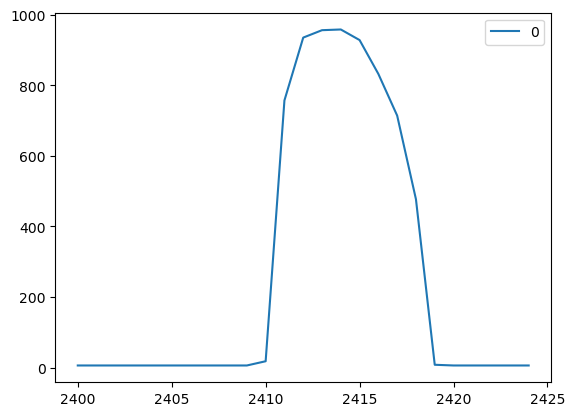

In [38]:
foo = cfin[year].copy()
foo.loc[:,:] = np.roll(foo, -5, axis=0)

foo.loc[24*100:24*101].plot()